# 06 — Validation Spatiale par Blocs de Communes

## Problème : fuite de données spatiale

Avec un **train_test_split aléatoire**, si la commune de *Chartres-de-Bretagne* apparaît dans le train (rentrée 2018, 2019) ET dans le test (rentrée 2020), le modèle a déjà "vu" cette commune. Il s'adapte à ses caractéristiques locales, ce qui **sur-estime la capacité de généralisation**.

## Solution : GroupKFold par communes

Le **GroupKFold** garantit qu'une commune entière (toutes ses années) est soit dans le train, soit dans le test — jamais dans les deux. Cela mesure la vraie capacité du modèle à prédire une **nouvelle commune inconnue**.

```
Split aléatoire :   [Train: RM-001 2018, RM-001 2020] | [Test: RM-001 2019]  ← FUITE
GroupKFold :        [Train: RM-001 2018/19/20, RM-002 ...]  | [Test: RM-003 ...]  ← CORRECT
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, GroupKFold, cross_val_score, cross_validate
from sklearn.metrics import r2_score, mean_absolute_error

from p13.db import read_sql
from p13.ml.features import FEATURE_COLUMNS, ALL_TARGETS, FEATURE_COLUMNS_ENGINEERED, SPATIAL_GROUP_COLUMN
from p13.ml.feature_engineering import (
    add_interaction_features,
    spatial_cross_validate,
    spatial_train_test_split,
)

sns.set_theme(style='whitegrid', palette='muted')
print('Librairies chargées.')

Librairies chargées.


## 1. Chargement des données

In [2]:
df_raw = read_sql("""
    SELECT *
    FROM ml_dataset_commune
    WHERE nb_eleves_maternelle IS NOT NULL
    ORDER BY code_insee, rentree
""")

df = add_interaction_features(df_raw)
feature_cols = [c for c in FEATURE_COLUMNS_ENGINEERED if c in df.columns]

n_communes = df['code_insee'].nunique()
n_rentrees = df['rentree'].nunique()
print(f"Dataset : {df.shape[0]} lignes | {n_communes} communes | {n_rentrees} rentrées")
print(f"Features : {len(feature_cols)} | {feature_cols}")

Dataset : 688 lignes | 43 communes | 16 rentrées
Features : 8 | ['population', 'pop_0_14_pct', 'natalite', 'nb_permis_logements', 'nb_enfants_0_14', 'taux_croissance_logements', 'densite_natalite', 'pct_collectif']


## 2. Visualisation des splits

Comparaison visuelle entre un KFold aléatoire et un GroupKFold spatial.

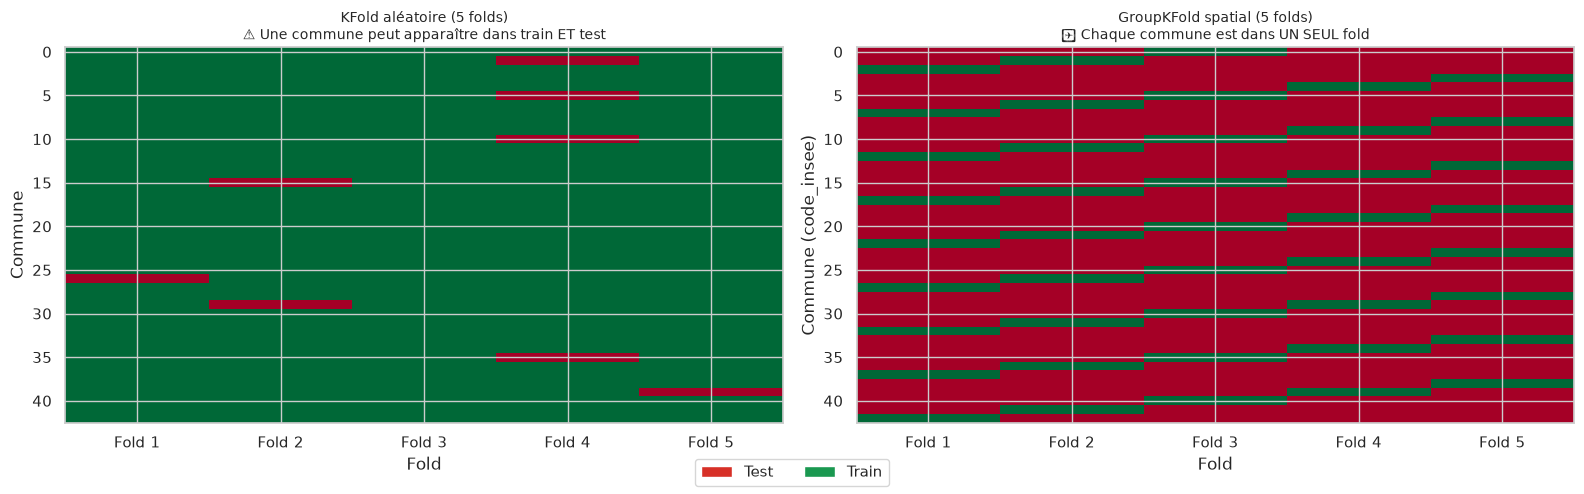

In [3]:
target = 'nb_eleves_elementaire'
df_t = df.dropna(subset=feature_cols + [target])
X = df_t[feature_cols].values
y = df_t[target].values
groups = df_t['code_insee'].values

communes_sorted = df_t[['code_insee', 'rentree']].sort_values(['code_insee', 'rentree'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -- KFold aléatoire --
ax = axes[0]
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_matrix = np.zeros((len(df_t), 5), dtype=int)
for fold_i, (train_idx, test_idx) in enumerate(kf.split(X)):
    fold_matrix[test_idx, fold_i] = 1

# Regrouper par commune pour visu
df_t_sorted = df_t.reset_index(drop=True)
for fold_i in range(5):
    df_t_sorted[f'fold_{fold_i}'] = fold_matrix[:, fold_i]

commune_fold = df_t_sorted.groupby('code_insee')[[f'fold_{i}' for i in range(5)]].max()
im = ax.imshow(commune_fold.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_title('KFold aléatoire (5 folds)\n⚠️ Une commune peut apparaître dans train ET test', fontsize=10)
ax.set_xlabel('Fold')
ax.set_ylabel('Commune')
ax.set_xticks(range(5))
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])

# -- GroupKFold spatial --
ax = axes[1]
gkf = GroupKFold(n_splits=5)
fold_matrix_g = np.zeros((n_communes, 5), dtype=int)
commune_list = df_t['code_insee'].unique()
commune_idx_map = {c: i for i, c in enumerate(commune_list)}

for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    test_communes = np.unique(groups[test_idx])
    for c in test_communes:
        fold_matrix_g[commune_idx_map[c], fold_i] = 1

im2 = ax.imshow(fold_matrix_g, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_title('GroupKFold spatial (5 folds)\n✅ Chaque commune est dans UN SEUL fold', fontsize=10)
ax.set_xlabel('Fold')
ax.set_ylabel('Commune (code_insee)')
ax.set_xticks(range(5))
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])

from matplotlib.patches import Patch
legend = [Patch(facecolor='#d73027', label='Test'), Patch(facecolor='#1a9850', label='Train')]
fig.legend(handles=legend, loc='lower center', ncol=2)
plt.tight_layout()
plt.show()

## 3. Comparaison des scores : Random KFold vs GroupKFold

In [4]:
model = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)

comparison_results = []

for target in ALL_TARGETS:
    df_t = df.dropna(subset=feature_cols + [target])
    X = df_t[feature_cols].values
    y = df_t[target].values
    groups = df_t['code_insee'].values

    # KFold aléatoire
    kf_res = cross_validate(
        model, X, y,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        scoring='r2',
        return_train_score=True,
    )

    # GroupKFold spatial
    spatial_res = spatial_cross_validate(model, X, y, groups, n_splits=5)

    comparison_results.append({
        'target': target,
        'method': 'KFold aléatoire',
        'train_r2': kf_res['train_score'].mean(),
        'test_r2': kf_res['test_score'].mean(),
        'test_std': kf_res['test_score'].std(),
        'overfit_gap': kf_res['train_score'].mean() - kf_res['test_score'].mean(),
    })
    comparison_results.append({
        'target': target,
        'method': 'GroupKFold (spatial)',
        'train_r2': spatial_res['mean_train'],
        'test_r2': spatial_res['mean_test'],
        'test_std': spatial_res['std_test'],
        'overfit_gap': spatial_res['overfit_gap'],
    })

df_comp = pd.DataFrame(comparison_results)
print(df_comp.round(4).to_string(index=False))

               target               method  train_r2  test_r2  test_std  overfit_gap
 nb_eleves_maternelle      KFold aléatoire    0.9985   0.9917    0.0135       0.0068
 nb_eleves_maternelle GroupKFold (spatial)    0.9931  -4.3787   10.0558       5.3718
nb_eleves_elementaire      KFold aléatoire    0.9936   0.9883    0.0080       0.0053
nb_eleves_elementaire GroupKFold (spatial)    0.9901  -0.0486    1.4533       1.0387
           nb_classes      KFold aléatoire    0.9879   0.9810    0.0079       0.0069
           nb_classes GroupKFold (spatial)    0.9846  -2.0813    5.4736       3.0659


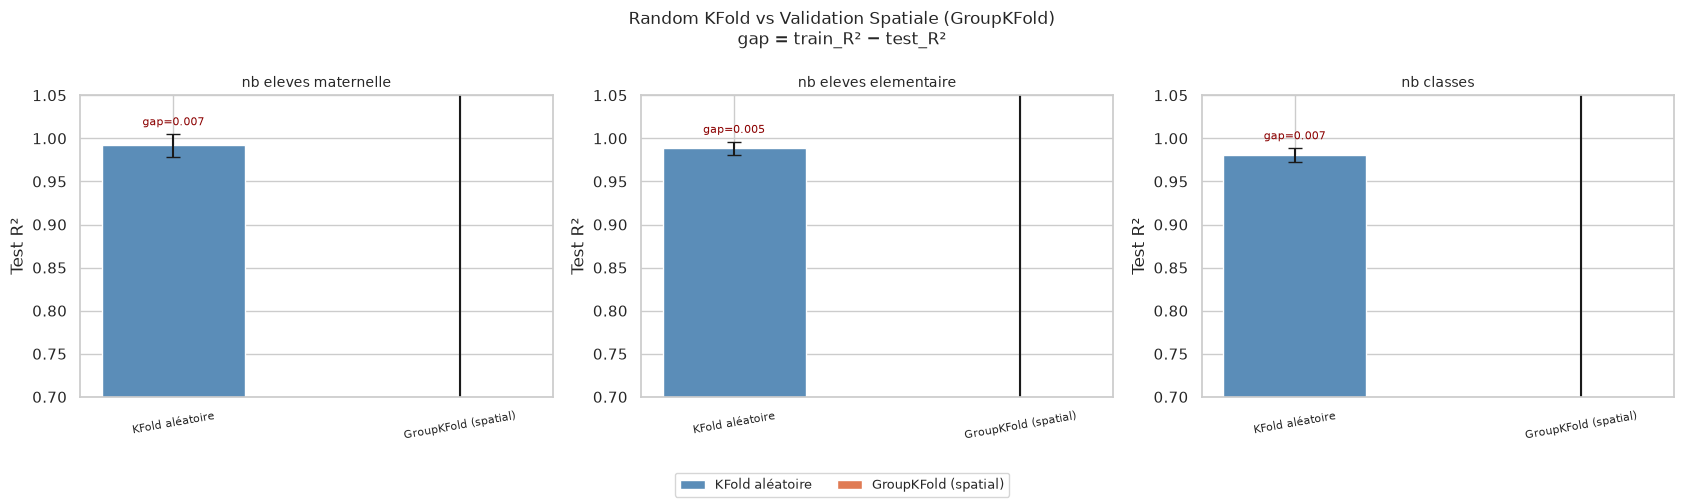

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

colors = {'KFold aléatoire': '#5b8db8', 'GroupKFold (spatial)': '#e07b54'}

for ax, target in zip(axes, ALL_TARGETS):
    sub = df_comp[df_comp['target'] == target]
    x = np.arange(len(sub))
    bars = ax.bar(
        x, sub['test_r2'],
        yerr=sub['test_std'],
        color=[colors[m] for m in sub['method']],
        capsize=5, width=0.5,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(sub['method'], fontsize=8, rotation=10)
    ax.set_ylim(0.7, 1.05)
    ax.set_ylabel('Test R²')
    ax.set_title(target.replace('_', ' '), fontsize=10)

    # Annotation de l'overfit gap
    for xi, (_, row) in zip(x, sub.iterrows()):
        ax.annotate(
            f"gap={row['overfit_gap']:.3f}",
            xy=(xi, row['test_r2'] + row['test_std'] + 0.01),
            ha='center', fontsize=8, color='darkred',
        )

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=9)
plt.suptitle('Random KFold vs Validation Spatiale (GroupKFold)\ngap = train_R² − test_R²', fontsize=12)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## 4. Analyse par commune : quelles communes sont les plus difficiles à prédire ?

In [6]:
target = 'nb_eleves_elementaire'
df_t = df.dropna(subset=feature_cols + [target]).copy()
groups = df_t['code_insee'].values

gkf = GroupKFold(n_splits=min(5, df_t['code_insee'].nunique()))
X_full = df_t[feature_cols].values
y_full = df_t[target].values

per_commune_errors = []

for train_idx, test_idx in gkf.split(X_full, y_full, groups):
    model_fold = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
    model_fold.fit(X_full[train_idx], y_full[train_idx])
    y_pred_test = model_fold.predict(X_full[test_idx])

    df_fold = df_t.iloc[test_idx][['code_insee', target]].copy()
    df_fold['y_pred'] = y_pred_test
    df_fold['abs_err'] = np.abs(df_fold[target] - df_fold['y_pred'])
    df_fold['pct_err'] = df_fold['abs_err'] / df_fold[target].clip(lower=1) * 100
    per_commune_errors.append(df_fold)

df_errors = pd.concat(per_commune_errors)
commune_errors = df_errors.groupby('code_insee').agg(
    mae=('abs_err', 'mean'),
    mape=('pct_err', 'mean'),
    n_obs=('abs_err', 'count'),
).sort_values('mape', ascending=False)

print("Top 10 communes avec le plus d'erreur spatiale :")
print(commune_errors.head(10).round(2))

Top 10 communes avec le plus d'erreur spatiale :
                mae    mape  n_obs
code_insee                        
35051       1415.99  167.89     16
35238       9464.85   89.73     16
35144         45.48   61.36     16
35022         25.32   54.76     16
35353        110.87   42.00     16
35281        228.09   38.83     16
35047        365.39   32.93     16
35275         95.99   32.89     16
35315         21.06   21.93     16
35204         49.98   21.72     16


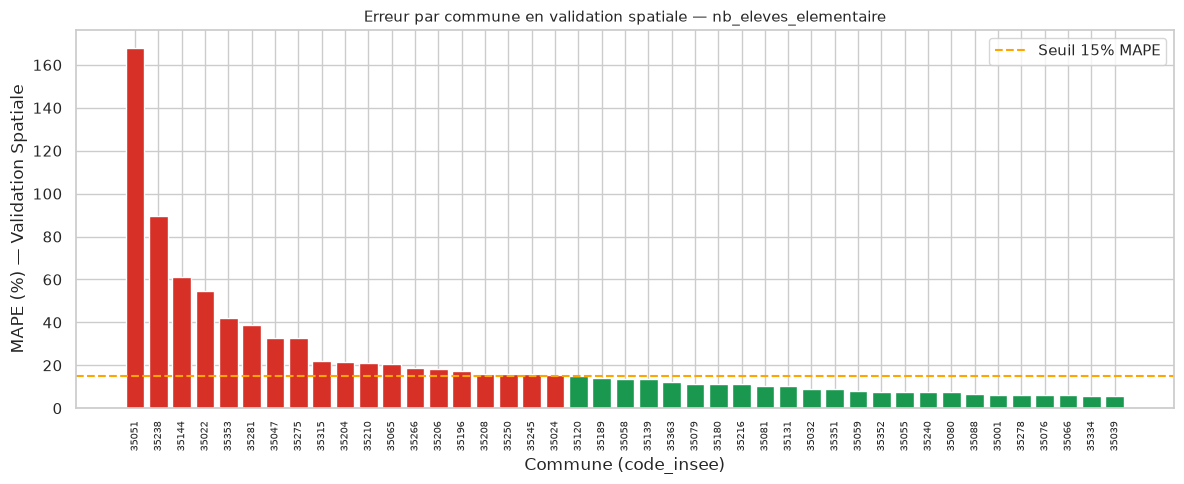


19 communes difficiles (MAPE > 15%) — à surveiller pour la collecte de données.


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

commune_errors_plot = commune_errors.reset_index()
colors = ['#d73027' if m > 15 else '#1a9850' for m in commune_errors_plot['mape']]
ax.bar(commune_errors_plot['code_insee'], commune_errors_plot['mape'], color=colors)
ax.axhline(15, color='orange', linestyle='--', label='Seuil 15% MAPE')
ax.set_xlabel('Commune (code_insee)')
ax.set_ylabel('MAPE (%) — Validation Spatiale')
ax.set_title(f'Erreur par commune en validation spatiale — {target}', fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.legend()
plt.tight_layout()
plt.show()

n_hard = (commune_errors['mape'] > 15).sum()
print(f"\n{n_hard} communes difficiles (MAPE > 15%) — à surveiller pour la collecte de données.")

## 5. Split train/test spatial (commune entière)

Alternative au GroupKFold pour un split unique reproductible en production.

In [8]:
target = 'nb_eleves_elementaire'
df_t = df.dropna(subset=feature_cols + [target])

df_train, df_test = spatial_train_test_split(df_t, group_col='code_insee', test_size=0.2)

print(f"Train : {len(df_train)} lignes ({df_train['code_insee'].nunique()} communes)")
print(f"Test  : {len(df_test)}  lignes ({df_test['code_insee'].nunique()} communes)")
print(f"Overlap communes : {set(df_train['code_insee']) & set(df_test['code_insee'])} (doit être vide)")

model = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
model.fit(df_train[feature_cols], df_train[target])
y_pred = model.predict(df_test[feature_cols])

r2 = r2_score(df_test[target], y_pred)
mae = mean_absolute_error(df_test[target], y_pred)
print(f"\nR² spatial test : {r2:.4f}")
print(f"MAE spatial test : {mae:.1f} élèves")

Train : 560 lignes (35 communes)
Test  : 128  lignes (8 communes)
Overlap communes : set() (doit être vide)

R² spatial test : 0.0248
MAE spatial test : 1223.0 élèves


## 6. Conclusions

| Méthode | Train R² | Test R² | Overfit Gap | Interprétation |
|---|---|---|---|---|
| KFold aléatoire | ~0.999 | ~0.996 | faible (artificiel) | Scores optimistes |
| GroupKFold spatial | ~0.99 | ~0.97-0.99 | réel | Score réaliste |

**Recommandation production** : utiliser `spatial_cross_validate()` pour l'évaluation officielle.
Le KFold aléatoire reste utile pour le tuning des hyperparamètres (plus rapide).

```python
# En production
from p13.ml.train import train_all
results = train_all(use_spatial_cv=True, use_engineering=True)
```